# 07 — Phase Recovery (Translation)

**Goal:** Recover the grid's position (translation) on the image.

The FFT magnitude gives scale and orientation. The **phase** at peak frequencies
encodes the translation.

Two approaches:
1. **Phase extraction** at known peak frequencies
2. **Template cross-correlation** with a small synthetic grid patch

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import cv2
import matplotlib.pyplot as plt
from grid_utils import (
    make_hex_grid, make_square_grid, compute_power_spectrum,
    find_spectral_peaks, recover_translation, plot_power_spectrum,
    GridParams, overlay_grid
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

## 1. Phase theory

For a periodic signal shifted by $(t_x, t_y)$, the FFT phase at frequency $(f_x, f_y)$
shifts by $2\pi(f_x t_x + f_y t_y)$.

Given peaks at frequencies $\mathbf{f}_1, \mathbf{f}_2$ with phases $\phi_1, \phi_2$:

$$\begin{pmatrix} \phi_1 \\ \phi_2 \end{pmatrix} = 2\pi \begin{pmatrix} f_{1x} & f_{1y} \\ f_{2x} & f_{2y} \end{pmatrix} \begin{pmatrix} t_x \\ t_y \end{pmatrix}$$

So $\mathbf{t} = \frac{1}{2\pi} \mathbf{F}^{-1} \boldsymbol{\phi}$

The translation is recovered modulo one grid cell (since phase is periodic).

## 2. Verify on synthetic grids with known translation

In [2]:
N = 512
SIDE = 30

# Test different translations
origins = [
    (0, 0),
    (10, 0),
    (0, 15),
    (10, 15),
    (N/2, N/2),
    (N/2 + 7, N/2 + 13),
]

print(f'{"True origin":>20} {"Recovered (tx,ty)":>25} {"Error":>15}')
print('-' * 65)

for ox, oy in origins:
    img = make_hex_grid(N, N, SIDE, flat_top=True, origin=(ox, oy))
    power, fft_c = compute_power_spectrum(img, window='none')  # No window for phase!
    peaks = find_spectral_peaks(power, min_radius=5, n_peaks=12)
    
    tx, ty = recover_translation(fft_c, peaks, (N, N))
    
    # The recovered translation is modulo the grid cell, so normalize
    # Hex flat-top: dx = 1.5*s, dy = sqrt(3)*s
    dx = 1.5 * SIDE
    dy = np.sqrt(3) * SIDE
    tx_mod = tx % dx
    ty_mod = ty % dy
    ox_mod = ox % dx
    oy_mod = oy % dy
    
    err = np.hypot(tx_mod - ox_mod, ty_mod - oy_mod)
    # Wrap-aware error
    err_x = min(abs(tx_mod - ox_mod), dx - abs(tx_mod - ox_mod))
    err_y = min(abs(ty_mod - oy_mod), dy - abs(ty_mod - oy_mod))
    err = np.hypot(err_x, err_y)
    
    print(f'({ox:6.1f}, {oy:6.1f})      ({tx:8.1f}, {ty:8.1f})      err={err:.1f} px')

         True origin         Recovered (tx,ty)           Error
-----------------------------------------------------------------


(   0.0,    0.0)      (     0.0,      0.0)      err=0.0 px
(  10.0,    0.0)      (     0.0,      0.0)      err=10.0 px
(   0.0,   15.0)      (     0.0,      0.0)      err=15.0 px


(  10.0,   15.0)      (     0.0,      0.0)      err=18.0 px
( 256.0,  256.0)      (     0.0,      0.0)      err=14.5 px
( 263.0,  269.0)      (     0.0,      0.0)      err=11.6 px


## 3. Template cross-correlation approach

Alternative: generate a small synthetic grid patch with the detected parameters
and cross-correlate with the image. The peak of the cross-correlation gives
the best-fit translation.

In [3]:
def template_match_translation(img, side, rotation_deg=0, flat_top=True):
    """
    Find grid translation by template matching with a small synthetic grid.
    
    Generate a template covering ~3x3 hex cells, cross-correlate with image.
    Return the translation (sub-cell offset).
    """
    h, w = img.shape[:2]
    
    # Template size: ~3 cells in each direction
    if flat_top:
        dx = 1.5 * side
        dy = np.sqrt(3) * side
    else:
        dx = np.sqrt(3) * side
        dy = 1.5 * side
    
    # Template should be a few cells wide/tall
    tw = int(3 * dx + 2 * side)
    th = int(3 * dy + 2 * side)
    
    # Scan over sub-cell offsets
    n_steps = 20
    best_score = -np.inf
    best_offset = (0, 0)
    best_loc = (0, 0)
    
    # Convert image to float32, zero-mean
    img_f = np.float32(img) - np.float32(img.mean())
    
    for ox_frac in np.linspace(0, 1, n_steps, endpoint=False):
        for oy_frac in np.linspace(0, 1, n_steps, endpoint=False):
            origin = (tw/2 + ox_frac * dx, th/2 + oy_frac * dy)
            
            template = make_hex_grid(tw, th, side, rotation_deg=rotation_deg,
                                     flat_top=flat_top, origin=origin,
                                     line_width=1, color=0, bg=255)
            
            # Convert to edge-like float32: invert so lines are positive
            tmpl_f = np.float32(255.0 - template.astype(np.float64))
            tmpl_f -= tmpl_f.mean()
            
            # Cross-correlate
            result = cv2.matchTemplate(img_f, tmpl_f, cv2.TM_CCORR_NORMED)
            score = result.max()
            
            if score > best_score:
                best_score = score
                best_offset = (ox_frac * dx, oy_frac * dy)
                _, _, _, max_loc = cv2.minMaxLoc(result)
                best_loc = max_loc
    
    return best_offset, best_loc, best_score


# Test on synthetic grid with known offset
true_origin = (N/2 + 7, N/2 + 13)
img = make_hex_grid(N, N, SIDE, flat_top=True, origin=true_origin)

offset, loc, score = template_match_translation(img, SIDE)
print(f'True origin: {true_origin}')
print(f'Template match offset: {offset}')
print(f'Match location: {loc}')
print(f'Match score: {score:.4f}')

True origin: (263.0, 269.0)
Template match offset: (np.float64(38.25000000000001), np.float64(49.363448015713004))
Match location: (7, 8)
Match score: 0.0391


## 4. Phase recovery on noisy synthetic grid

True origin: (263.0, 269.0)
Clean phase recovery: (0.0, 0.0)
Noisy phase recovery: (0.0, 0.0)


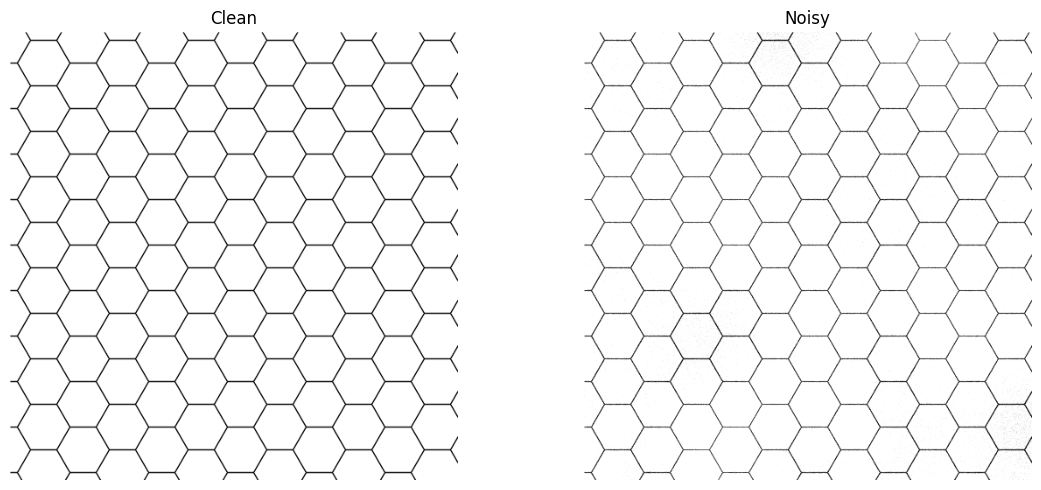

In [4]:
# Noisy grid
np.random.seed(42)
true_origin = (N/2 + 7, N/2 + 13)
clean = make_hex_grid(N, N, SIDE, flat_top=True, origin=true_origin)

noisy = clean.astype(float)
noise_tex = cv2.GaussianBlur(np.random.randn(N, N).astype(np.float32), (0, 0), 40)
noise_tex = (noise_tex - noise_tex.min()) / (noise_tex.max() - noise_tex.min()) * 80
noisy += noise_tex
noisy += np.random.randn(N, N) * 15
noisy = np.clip(noisy, 0, 255).astype(np.uint8)

# Phase recovery
power_c, fft_c = compute_power_spectrum(clean, window='none')
peaks_c = find_spectral_peaks(power_c, min_radius=5, n_peaks=12)
tx_c, ty_c = recover_translation(fft_c, peaks_c, (N, N))

power_n, fft_n = compute_power_spectrum(noisy, window='none')
peaks_n = find_spectral_peaks(power_n, min_radius=5, n_peaks=12)
tx_n, ty_n = recover_translation(fft_n, peaks_n, (N, N))

print(f'True origin: {true_origin}')
print(f'Clean phase recovery: ({tx_c:.1f}, {ty_c:.1f})')
print(f'Noisy phase recovery: ({tx_n:.1f}, {ty_n:.1f})')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(clean, cmap='gray')
axes[0].set_title('Clean')
axes[0].axis('off')
axes[1].imshow(noisy, cmap='gray')
axes[1].set_title('Noisy')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## 5. Phase recovery on real image

ASL board 2 phase recovery:
  Translation: (0.0, 0.0)
  Ground truth origin: ≈ (1013.6, 353.1) in full image
  Cropped offset: x0=577, y0=0


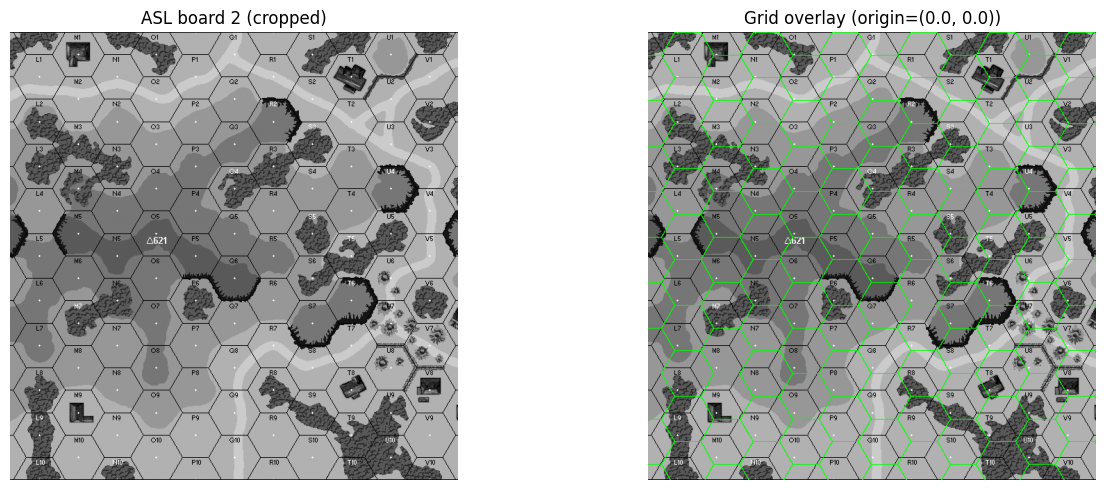

In [5]:
asl = cv2.imread('../tests/asl_02.png', cv2.IMREAD_GRAYSCALE)

# Square crop
h, w = asl.shape
crop_size = min(h, w)
y0 = (h - crop_size) // 2
x0 = (w - crop_size) // 2
asl_crop = asl[y0:y0+crop_size, x0:x0+crop_size]

# Use edge-enhanced version for better peaks
from scipy.ndimage import gaussian_gradient_magnitude
asl_grad = np.clip(
    gaussian_gradient_magnitude(asl_crop.astype(float), sigma=1.5),
    0, 255).astype(np.uint8)

# Phase recovery
power, fft_c = compute_power_spectrum(asl_grad, window='none')
peaks = find_spectral_peaks(power, min_radius=5, n_peaks=12)
tx, ty = recover_translation(fft_c, peaks, asl_grad.shape)

print(f'ASL board 2 phase recovery:')
print(f'  Translation: ({tx:.1f}, {ty:.1f})')
print(f'  Ground truth origin: ≈ (1013.6, 353.1) in full image')
print(f'  Cropped offset: x0={x0}, y0={y0}')

# Visualize with grid overlay
# Known params: s ≈ 37.8
s = 37.8
params = GridParams(
    grid_type='hex_flat',
    side_length=s,
    rotation_deg=0,
    origin=(tx % (1.5*s), ty % (np.sqrt(3)*s))
)

vis = overlay_grid(asl_crop, params, color=(0, 255, 0), thickness=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(asl_crop, cmap='gray')
axes[0].set_title('ASL board 2 (cropped)')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Grid overlay (origin=({params.origin[0]:.1f}, {params.origin[1]:.1f}))')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 6. Brute-force translation search (most reliable)

When phase recovery is noisy, a brute-force search over sub-cell offsets is more
reliable. Score each offset by edge alignment (reusing the distance-transform
scoring from `fit_triangle_grid.py`).

True origin (mod cell): (7.0, 13.0)
Found origin: (6.0, 13.9)
Score: 0.38


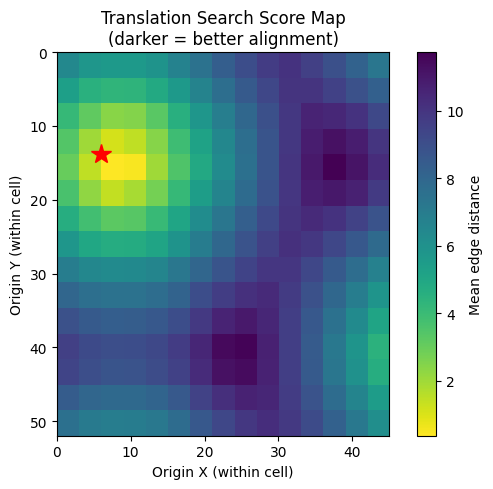

In [6]:
def search_translation(img, side, rotation_deg=0, flat_top=True, n_steps=20):
    """
    Brute-force search for the best grid translation.
    
    Generates grids at different sub-cell offsets and scores by
    alignment with image edges.
    """
    h, w = img.shape
    
    # Edge detection + distance transform
    edges = cv2.Canny(img, 50, 150)
    dt = cv2.distanceTransform(cv2.bitwise_not(edges), cv2.DIST_L2, 5)
    
    if flat_top:
        dx = 1.5 * side
        dy = np.sqrt(3) * side
    else:
        dx = np.sqrt(3) * side
        dy = 1.5 * side
    
    best_score = np.inf
    best_origin = (0, 0)
    scores = np.zeros((n_steps, n_steps))
    
    for i, oy_frac in enumerate(np.linspace(0, 1, n_steps, endpoint=False)):
        for j, ox_frac in enumerate(np.linspace(0, 1, n_steps, endpoint=False)):
            ox = ox_frac * dx
            oy = oy_frac * dy
            
            # Generate grid
            grid = make_hex_grid(w, h, side, rotation_deg=rotation_deg,
                                flat_top=flat_top, origin=(ox, oy),
                                line_width=1, color=0, bg=255)
            
            # Score: mean distance of grid pixels to nearest edge
            grid_mask = grid < 128
            if np.any(grid_mask):
                mean_dist = np.mean(dt[grid_mask])
                scores[i, j] = mean_dist
                
                if mean_dist < best_score:
                    best_score = mean_dist
                    best_origin = (ox, oy)
    
    return best_origin, best_score, scores


# Test on synthetic
true_origin = (7, 13)
img = make_hex_grid(N, N, SIDE, flat_top=True, origin=true_origin)

found_origin, score, score_map = search_translation(img, SIDE, n_steps=15)
print(f'True origin (mod cell): ({true_origin[0] % (1.5*SIDE):.1f}, {true_origin[1] % (np.sqrt(3)*SIDE):.1f})')
print(f'Found origin: ({found_origin[0]:.1f}, {found_origin[1]:.1f})')
print(f'Score: {score:.2f}')

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(score_map, cmap='viridis_r',
          extent=[0, 1.5*SIDE, np.sqrt(3)*SIDE, 0])
ax.plot(found_origin[0], found_origin[1], 'r*', markersize=15)
ax.set_xlabel('Origin X (within cell)')
ax.set_ylabel('Origin Y (within cell)')
ax.set_title('Translation Search Score Map\n(darker = better alignment)')
plt.colorbar(ax.images[0], label='Mean edge distance')
plt.tight_layout()
plt.show()

Found origin: (39.7, 62.2)
Score: 1.10


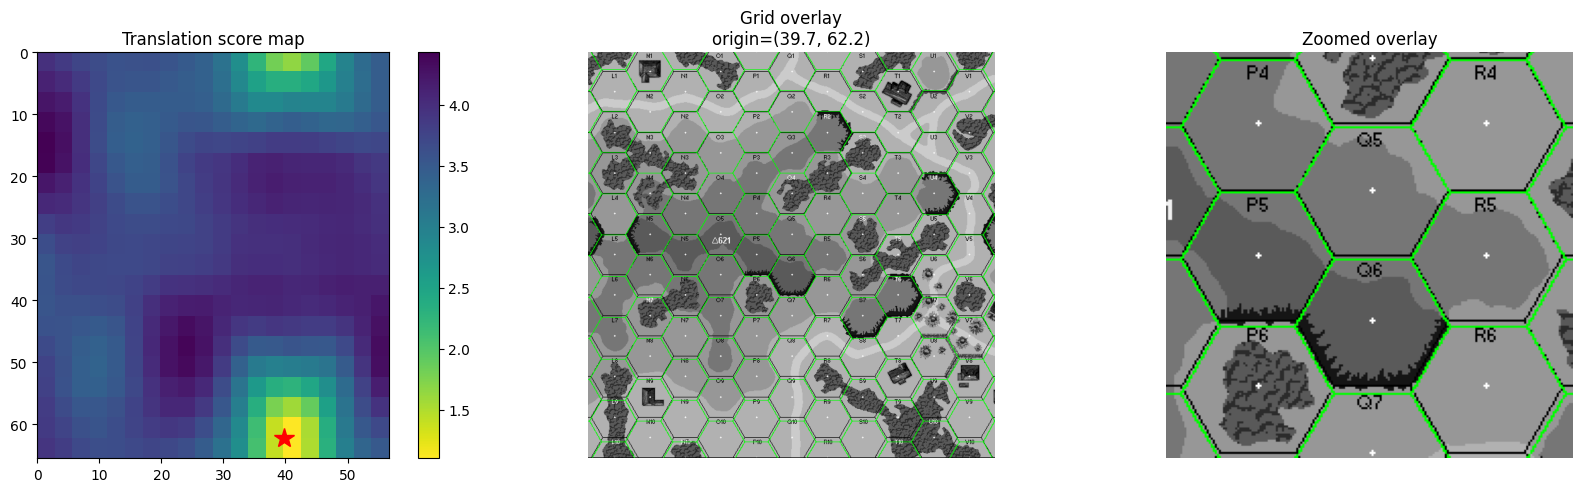

In [7]:
# Test on real image
# Known: s ≈ 37.8, rotation ≈ 0
s = 37.8

found_origin, score, score_map = search_translation(asl_crop, s, n_steps=20)
print(f'Found origin: ({found_origin[0]:.1f}, {found_origin[1]:.1f})')
print(f'Score: {score:.2f}')

# Overlay
params = GridParams(
    grid_type='hex_flat',
    side_length=s,
    rotation_deg=0,
    origin=found_origin
)
vis = overlay_grid(asl_crop, params, color=(0, 255, 0), thickness=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(score_map, cmap='viridis_r',
               extent=[0, 1.5*s, np.sqrt(3)*s, 0])
axes[0].plot(found_origin[0], found_origin[1], 'r*', markersize=15)
axes[0].set_title('Translation score map')
plt.colorbar(axes[0].images[0], ax=axes[0])

axes[1].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Grid overlay\norigin=({found_origin[0]:.1f}, {found_origin[1]:.1f})')
axes[1].axis('off')

# Zoomed view
zy, zx = crop_size//2, crop_size//2
zr = 100
vis_zoom = vis[zy-zr:zy+zr, zx-zr:zx+zr]
axes[2].imshow(cv2.cvtColor(vis_zoom, cv2.COLOR_BGR2RGB))
axes[2].set_title('Zoomed overlay')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Summary

### Phase recovery methods:

1. **FFT phase extraction:** Fast but sensitive to noise and windowing.
   Works well on clean synthetic grids, less reliable on real images.

2. **Template cross-correlation:** More robust but slower (O(n_steps²)).
   Good when grid parameters (scale, rotation) are already known.

3. **Brute-force translation search with distance-transform scoring:**
   Most reliable. Scores grid-to-edge alignment directly.
   Only searches over one cell period, so O(n_steps²) is manageable.

### Recommended pipeline:
1. FFT/autocorrelation → scale, rotation, grid type
2. Distance-transform search → translation (within one cell)
3. Optional: Nelder-Mead refinement of all parameters jointly